In [3]:
"""
Energy Conditions Analysis
Eq. (4)-(8) and NEC
"""


'\nEnergy Conditions Analysis\nEq. (4)-(8) and NEC\n'

In [20]:
%matplotlib inline
import sys; sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
import yaml

In [21]:
with open('../config/params.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

In [22]:
rho_s = config['dark_matter']['rho_s']
r_s = config['dark_matter']['r_s']
C1 = config['wormhole']['C1']
Q = config['wormhole']['Q']

In [27]:
from src.dark_matter import DarkMatterProfile
from src.shape_function import ShapeFunction
from src.energy_conditions import EnergyConditions

sf = ShapeFunction(rho_s, r_s, C1, Q)
ec = EnergyConditions(sf)

r_values = np.linspace(1.1, 10, 500)
rho_vals = [ec.rho(r) for r in r_values]
pr_vals = [ec.pressure_radial(r) for r in r_values]
pt_vals = [ec.pressure_tangential(r) for r in r_values]



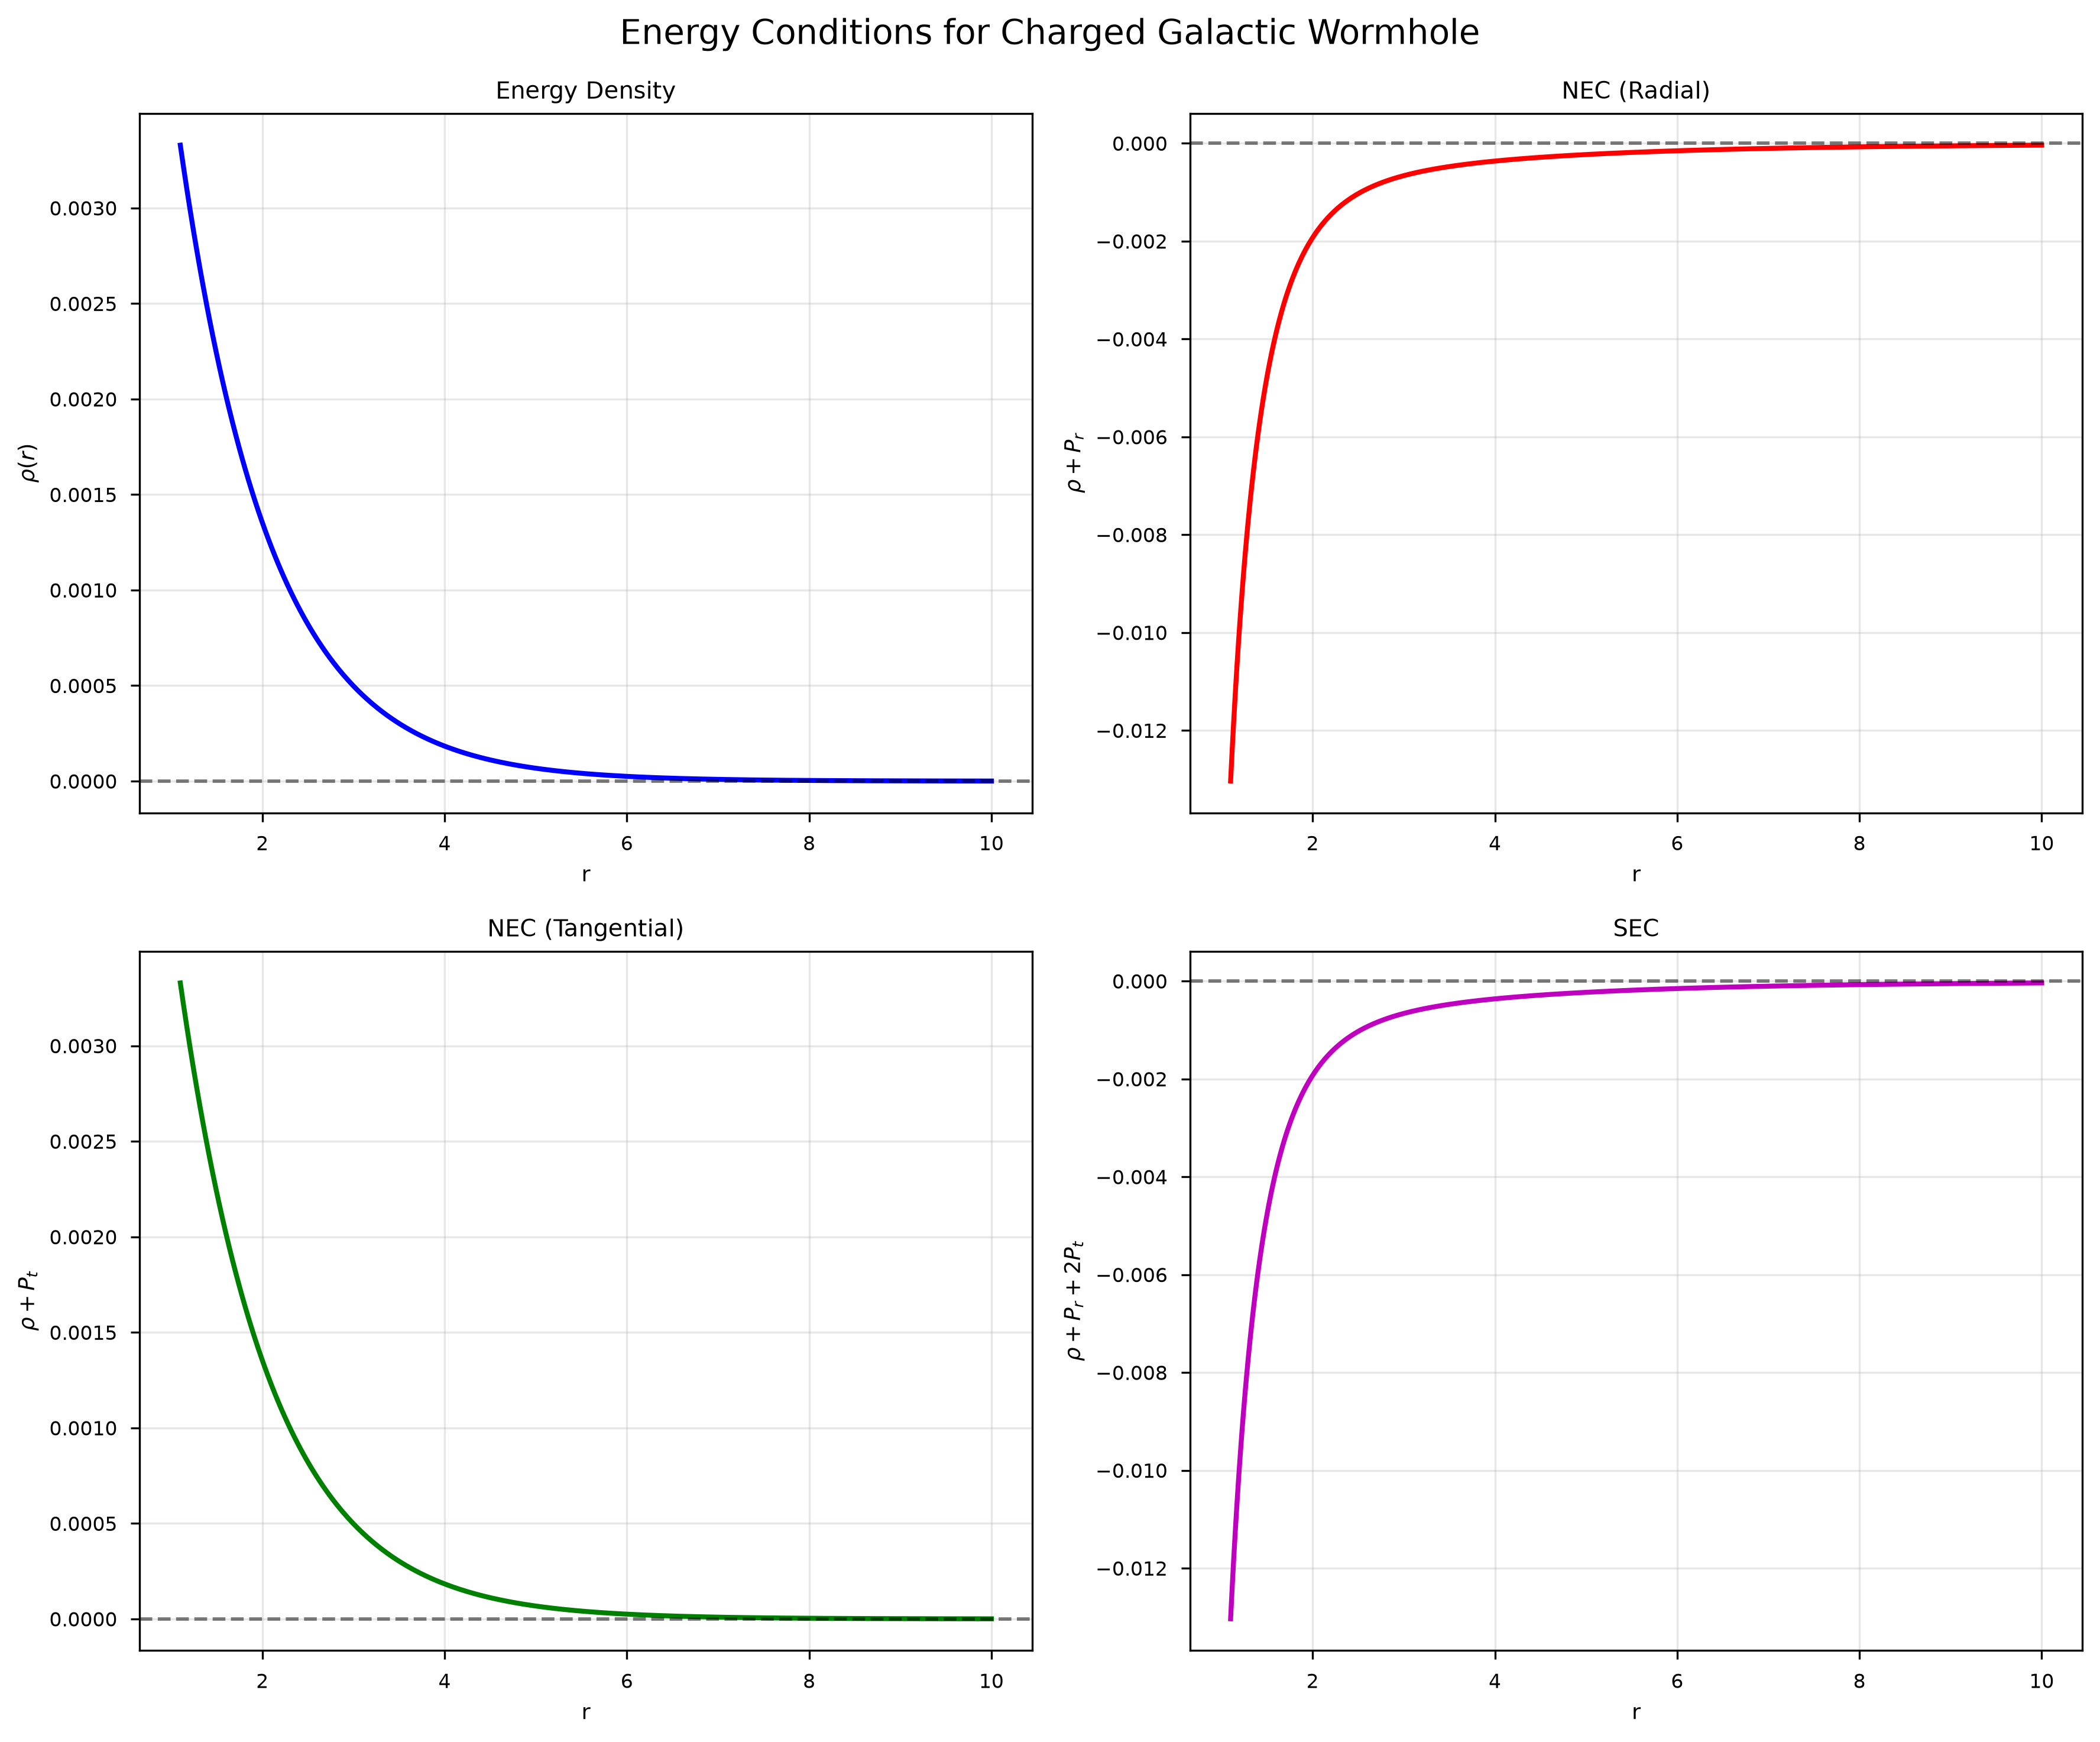

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Energy density
axes[0, 0].plot(r_values, rho_vals, 'b-', linewidth=2)
axes[0, 0].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('r')
axes[0, 0].set_ylabel(r'$\rho(r)$')
axes[0, 0].set_title('Energy Density')
axes[0, 0].grid(True, alpha=0.3)

# 2. NEC Radial
axes[0, 1].plot(r_values, np.array(rho_vals) + np.array(pr_vals), 'r-', linewidth=2)
axes[0, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('r')
axes[0, 1].set_ylabel(r'$\rho + P_r$')
axes[0, 1].set_title('NEC (Radial)')
axes[0, 1].grid(True, alpha=0.3)

# 3. NEC Tangential
axes[1, 0].plot(r_values, np.array(rho_vals) + np.array(pt_vals), 'g-', linewidth=2)
axes[1, 0].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('r')
axes[1, 0].set_ylabel(r'$\rho + P_t$')
axes[1, 0].set_title('NEC (Tangential)')
axes[1, 0].grid(True, alpha=0.3)

# 4. SEC
axes[1, 1].plot(r_values, np.array(rho_vals) + np.array(pr_vals) + 2*np.array(pt_vals), 'm-', linewidth=2)
axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('r')
axes[1, 1].set_ylabel(r'$\rho + P_r + 2P_t$')
axes[1, 1].set_title('SEC')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Energy Conditions for Charged Galactic Wormhole', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/energy_conditions/energy_conditions.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
print("\nNEC Analysis:")
throat = sf.find_throat()
if throat:
    nec = ec.check_NEC(throat)
    print(f"At throat r₀ = {throat:.4f}:")
    print(f"  NEC Radial: {nec['radial']}")
    print(f"  NEC Tangential: {nec['tangential']}")
    print(f"  Exotic matter required: {nec['violated']}")


NEC Analysis:
At throat r₀ = 0.5048:
  NEC Radial: False
  NEC Tangential: True
  Exotic matter required: True
